# Notebook 01 – Data Loading & Contamination Detection

**Objetivo:** Cargar los datos de GC-MS, identificar y eliminar contaminantes (silanos, siloxanos, TMS, oximas), y preparar la matriz de intensidades limpia.

## Importe de librerías

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Rutas
DATA_RAW = Path('../data/raw')
DATA_PROC = Path('../data/processed')
FIGS = Path('../results/figures')
DATA_PROC.mkdir(parents=True, exist_ok=True)
FIGS.mkdir(parents=True, exist_ok=True)

print('✓ Librerías importadas')

✓ Librerías importadas


## 1. Carga de datos

In [3]:
# Cargar picos — hoja real del Excel
peaks = pd.read_excel(DATA_RAW / 'Proyect_DS_Picos.xlsx', sheet_name='Peak Area_Iñigo')

# Columnas de experimentos (tienen sufijo .CDF)
exp_cols = sorted([col for col in peaks.columns if col.startswith('Exp_')])

print('=' * 70)
print('DATOS CARGADOS')
print('=' * 70)
print(f'\nShape total: {peaks.shape}')
print(f'Compuestos únicos: {peaks["Compound Name"].nunique()}')
print(f'Experimentos ({len(exp_cols)}): {exp_cols}')
print(f'\nColumnas disponibles:')
for c in peaks.columns:
    print(f'  {c}')

print(f'\nPrimeros 10 compuestos:')
for i, name in enumerate(peaks['Compound Name'].unique()[:10]):
    print(f'  {i+1}. {name}')

DATOS CARGADOS

Shape total: (443, 31)
Compuestos únicos: 239
Experimentos (17): ['Exp_1.CDF', 'Exp_10.CDF', 'Exp_11.CDF', 'Exp_12.CDF', 'Exp_13.CDF', 'Exp_14.CDF', 'Exp_15.CDF', 'Exp_16.CDF', 'Exp_17.CDF', 'Exp_2.CDF', 'Exp_3.CDF', 'Exp_4.CDF', 'Exp_5.CDF', 'Exp_6.CDF', 'Exp_7.CDF', 'Exp_8.CDF', 'Exp_9.CDF']

Columnas disponibles:
  Compound Name
  Match Quality
  Est. Retention Time (min)
  Hit 1: Match Factor
  Hit 1: Reverse Match Factor
  Comments
  Hit 2: Compound
  Hit 2: Match Factor
  Hit 2: Reverse Match Factor
  Retention Indices
  Compound ID
  Interval ID
  Model Order
  Component #
  Exp_1.CDF
  Exp_10.CDF
  Exp_11.CDF
  Exp_12.CDF
  Exp_13.CDF
  Exp_14.CDF
  Exp_15.CDF
  Exp_16.CDF
  Exp_17.CDF
  Exp_2.CDF
  Exp_3.CDF
  Exp_4.CDF
  Exp_5.CDF
  Exp_6.CDF
  Exp_7.CDF
  Exp_8.CDF
  Exp_9.CDF

Primeros 10 compuestos:
  1. 2-Propenal
  2. N-Dimethylaminomethyl-tert.-butyl-isopropylphosphine
  3. Benzene, 1-chloro-3-fluoro-
  4. Isobutylene epoxide
  5. Acetone
  6. 2-Furancar

## 2. Detección y eliminación de los contaminantes

In [4]:
import re

# ============================================================
# PATRONES DE CONTAMINANTES GC-MS  (estilo %patrón%)
# Usa regex: más precisos que substring simple
# ============================================================

CONTAMINATION_PATTERNS = [
    # Silanos / siloxanos
    r'%silane%', r'%siloxane%', r'%disiloxane%', r'%trisiloxane%',
    r'%silicon%', r'%silica%',
    # Grupo sililo (muy específico: -silyl-)
    r'%silyl%',
    # Derivados TMS / TBDMS
    r'%\btms\b%', r'%trimethylsilyl%', r'%trimethylsilane%',
    r'%tert-butyl-dimethyl%', r'%\btbdms\b%', r'%dimethyl-silyl%',
    r'%t-butyldimethylsilyl%',
    # Oximas
    r'%oxime%', r'%\boxim\b%',
    # Ftalatos de plásticos
    r'%dibutyl phthalate%', r'%diethyl phthalate%', r'%bis\(2-ethylhexyl\)%',
    # Siloxanos cíclicos específicos
    r'%cyclopentasiloxane%', r'%cyclotetrasiloxane%',
    r'%decamethylcyclopentasiloxane%',
]

# Convertir formato %patrón% → regex .*patrón.*
compiled = [re.compile(p.replace('%', '.*'), re.IGNORECASE) for p in CONTAMINATION_PATTERNS]

def is_contamination(name):
    """True si el nombre coincide con algún patrón de contaminante."""
    if pd.isna(name):
        return False
    return any(pat.search(name) for pat in compiled)

peaks['is_contamination'] = peaks['Compound Name'].apply(is_contamination)

n_contam = peaks['is_contamination'].sum()
n_clean  = (~peaks['is_contamination']).sum()

print('=' * 70)
print('ANÁLISIS DE CONTAMINANTES')
print('=' * 70)
print(f'\nContaminantes detectados: {n_contam}  ({n_contam} filas, {peaks[peaks["is_contamination"]]["Compound Name"].nunique()} únicos)')
print(f'Compuestos limpios:       {n_clean}')
print(f'Porcentaje limpio:        {n_clean / len(peaks) * 100:.1f}%')

# Lista completa para revisión del usuario
contam_df = (
    peaks[peaks['is_contamination']][['Compound Name', 'Match Quality', 'Est. Retention Time (min)']]
    .sort_values('Compound Name')
    .reset_index(drop=True)
)
contam_df.index += 1

pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', 80)
print(f'\n--- Lista completa de contaminantes a eliminar ({len(contam_df)} filas) ---')
contam_df

ANÁLISIS DE CONTAMINANTES

Contaminantes detectados: 71  (71 filas, 26 únicos)
Compuestos limpios:       372
Porcentaje limpio:        84.0%

--- Lista completa de contaminantes a eliminar (71 filas) ---


,Compound Name,Match Quality,Est. Retention Time (min)
1,"1,1,1,3,5,7,9,11,11,11-Decamethyl-5-(trimethylsiloxy)hexasiloxane",Poor/No match,44.005283
2,"16-Methyl-heptadecane-1,2-diol, trimethylsilyl ether",Poor/No match,32.198667
3,"16-Methyl-heptadecane-1,2-diol, trimethylsilyl ether",Poor/No match,32.198667
4,"2-Methyl-2(p-methoxy)mandelate, bis(trimethylsilyl)-",Poor/No match,57.358617
5,"2-Methyl-2(p-methoxy)mandelate, bis(trimethylsilyl)-",Poor/No match,44.726600
6,2-[(Trimethylsilyl)oxy]-2-{4-[(trimethylsilyl)oxy]phenyl}ethanamine,Fair,31.667550
7,"3-Ethoxy-1,1,1,5,5,5-hexamethyl-3-(trimethylsiloxy)trisiloxane",Poor/No match,49.395417
8,"3-Hydroxymandelic acid, ethyl ester, di-TMS",Fair,21.870567
9,"3-Isopropoxy-1,1,1,7,7,7-hexamethyl-3,5,5-tris(trimethylsiloxy)tetrasiloxane",Poor/No match,37.549333
10,"3-Isopropoxy-1,1,1,7,7,7-hexamethyl-3,5,5-tris(trimethylsiloxy)tetrasiloxane",Poor/No match,47.816417


In [5]:
# Filtrar
peaks_clean = peaks[~peaks['is_contamination']].copy().reset_index(drop=True)

print(f'Picos después de limpiar: {len(peaks_clean)}')
print(f'Experimentos: {len(exp_cols)}')

Picos después de limpiar: 372
Experimentos: 17


## 3. Top 10 compuestos más intensos

In [6]:
exp_cols_sorted = sorted(exp_cols, key=lambda x: int(x.split('_')[1].split('.')[0]))

# Top 10 compuestos más intensos (suma total entre los 17 experimentos)
intensity_total = peaks_clean[exp_cols_sorted].sum(axis=1)
top10_idx = intensity_total.nlargest(10).index

top10 = peaks_clean.loc[top10_idx, ['Compound Name']].copy()
top10['Total Intensity'] = intensity_total[top10_idx].values
top10 = top10.reset_index(drop=True)
top10.index += 1

pd.set_option('display.max_colwidth', 70)
print('Top 10 compuestos más intensos (suma de los 17 experimentos):')
print('=' * 70)
for i, row in top10.iterrows():
    print(f'  {i:2d}. {row["Compound Name"]:<60}  {row["Total Intensity"]:.3e}')
top10

Top 10 compuestos más intensos (suma de los 17 experimentos):
   1. Indole, 3-[3-(4-morpholinyl)prop-1-enyl]-                     1.725e+11
   2. p-Cresol                                                      4.953e+08
   3. Acetone                                                       8.584e+07
   4. Indole, 3-methyl-                                             7.617e+07
   5. Indole                                                        7.062e+07
   6. Phenol, 4-ethyl-                                              1.172e+07
   7. Benzaldehyde                                                  7.227e+06
   8. Nonanoic acid                                                 5.895e+06
   9. Phenol                                                        5.544e+06
  10. Caryophyllene                                                 5.259e+06


,Compound Name,Total Intensity
1,"Indole, 3-[3-(4-morpholinyl)prop-1-enyl]-",1.724996e+11
2,p-Cresol,4.953193e+08
3,Acetone,8.583718e+07
4,"Indole, 3-methyl-",7.617083e+07
5,Indole,7.062421e+07
6,"Phenol, 4-ethyl-",1.171679e+07
7,Benzaldehyde,7.227192e+06
8,Nonanoic acid,5.894772e+06
9,Phenol,5.543639e+06
10,Caryophyllene,5.259302e+06


## 4. Visualización de los resultados

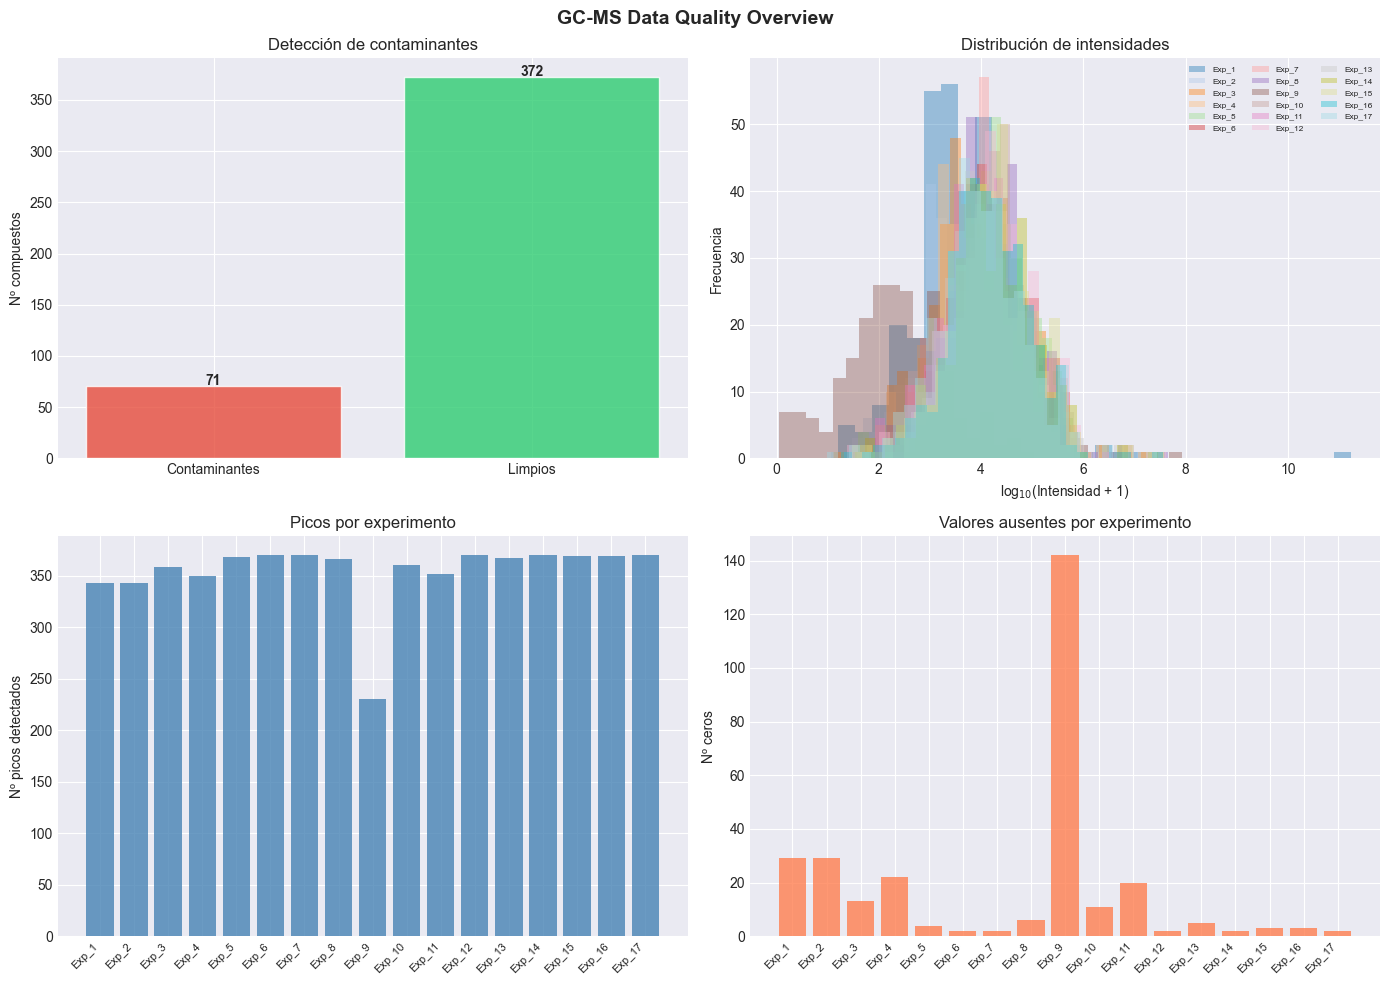

✓ Figura guardada: results/figures/01_data_quality.png


In [7]:
exp_labels = [col.replace('.CDF', '') for col in exp_cols_sorted]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('GC-MS Data Quality Overview', fontsize=14, fontweight='bold')

# -- Plot 1: Contaminantes vs Limpios
ax = axes[0, 0]
ax.bar(['Contaminantes', 'Limpios'], [n_contam, n_clean],
       color=['#e74c3c', '#2ecc71'], alpha=0.8, edgecolor='white')
ax.set_ylabel('Nº compuestos')
ax.set_title('Detección de contaminantes')
for bar, val in zip(ax.patches, [n_contam, n_clean]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', fontweight='bold')

# -- Plot 2: Distribución de intensidades (log10) por experimento
ax = axes[0, 1]
colors = plt.cm.tab20(np.linspace(0, 1, len(exp_cols_sorted)))
for col, color in zip(exp_cols_sorted, colors):
    vals = peaks_clean[col]
    vals = vals[vals > 0]
    ax.hist(np.log10(vals + 1), bins=30, alpha=0.4,
            label=col.replace('.CDF', ''), color=color)
ax.set_xlabel('log$_{10}$(Intensidad + 1)')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de intensidades')
ax.legend(fontsize=6, ncol=3)

# -- Plot 3: Picos detectados por experimento (intensidad > 0)
ax = axes[1, 0]
detected = (peaks_clean[exp_cols_sorted] > 0).sum()
ax.bar(range(len(exp_cols_sorted)), detected.values, color='steelblue', alpha=0.8)
ax.set_xticks(range(len(exp_cols_sorted)))
ax.set_xticklabels(exp_labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Nº picos detectados')
ax.set_title('Picos por experimento')

# -- Plot 4: Valores cero (ausencias) por experimento
ax = axes[1, 1]
zeros = (peaks_clean[exp_cols_sorted] == 0).sum()
ax.bar(range(len(exp_cols_sorted)), zeros.values, color='coral', alpha=0.8)
ax.set_xticks(range(len(exp_cols_sorted)))
ax.set_xticklabels(exp_labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Nº ceros')
ax.set_title('Valores ausentes por experimento')

plt.tight_layout()
plt.savefig(FIGS / '01_data_quality.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Figura guardada: results/figures/01_data_quality.png')

## 5. Guardado de los datos limpios

In [8]:
peaks_clean.to_csv(DATA_PROC / 'peaks_clean.csv', index=False)
print(f'✓ Guardado: data/processed/peaks_clean.csv')
print(f'  Shape: {peaks_clean.shape}')
print(f'  Columnas: {peaks_clean.columns.tolist()}')

✓ Guardado: data/processed/peaks_clean.csv
  Shape: (372, 32)
  Columnas: ['Compound Name', 'Match Quality', 'Est. Retention Time (min)', 'Hit 1: Match Factor', 'Hit 1: Reverse Match Factor', 'Comments', 'Hit 2: Compound', 'Hit 2: Match Factor', 'Hit 2: Reverse Match Factor', 'Retention Indices', 'Compound ID', 'Interval ID', 'Model Order', 'Component #', 'Exp_1.CDF', 'Exp_10.CDF', 'Exp_11.CDF', 'Exp_12.CDF', 'Exp_13.CDF', 'Exp_14.CDF', 'Exp_15.CDF', 'Exp_16.CDF', 'Exp_17.CDF', 'Exp_2.CDF', 'Exp_3.CDF', 'Exp_4.CDF', 'Exp_5.CDF', 'Exp_6.CDF', 'Exp_7.CDF', 'Exp_8.CDF', 'Exp_9.CDF', 'is_contamination']
